# Evaluación Formativa 1 — Análisis Exploratorio e Inferencial

**Curso:** MCDI501 — Estadística Computacional para la Toma de Decisiones  
**Integrantes:** Carolina Cortés Donoso · Pedro Espinoza Vicentela · Marcelo Corro Troncoso · Juan Pablo Valdebenito Loyola  
**Dataset:** Bank Marketing (UCI Machine Learning Repository)  
**Fecha:** 24/06/2026  
**Repositorio GitHub:** https://github.com/k1ngdom0fbullsh1t/proyecto-grupo4-mcdi501  


## Configuración del entorno

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings

warnings.filterwarnings('ignore')

# Reproducibilidad
SEED = 42
np.random.seed(SEED)

# Estilo global de gráficos
plt.rcParams.update({
    'figure.figsize': (10, 5),
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.dpi': 120,
})
sns.set_theme(style='whitegrid', palette='muted')

print('Entorno configurado correctamente.')

Entorno configurado correctamente.


---
## Sección 1 — Preparación y carga de datos

> Carga del dataset, verificación de estructura, tipos de variables, reporte de calidad y limpieza básica.


### 1.1 Carga del dataset

In [2]:
from pathlib import Path

# Detectar raíz del proyecto buscando la carpeta data/ hacia arriba
raiz = Path().resolve()
for _ in range(5):
    if (raiz / 'data').exists():
        break
    raiz = raiz.parent

RUTA = raiz / 'data' / 'raw' / 'bank-additional' / 'bank-additional-full.csv'
df = pd.read_csv(RUTA, sep=';')

print(f'Shape: {df.shape}')
print(f'Filas: {df.shape[0]:,} | Columnas: {df.shape[1]}')
df.head(3)

Shape: (41188, 21)
Filas: 41,188 | Columnas: 21


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


### 1.2 Tipos de variables

In [3]:
tipos_tabla = {
    'Variable':    ['age','job','marital','education','default','housing','loan',
                    'contact','month','day_of_week','duration','campaign',
                    'pdays','previous','poutcome',
                    'emp.var.rate','cons.price.idx','cons.conf.idx','euribor3m','nr.employed',
                    'y'],
    'Tipo estadístico': [
        'Numérica discreta','Categórica nominal','Categórica nominal','Categórica ordinal',
        'Categórica nominal','Categórica nominal','Categórica nominal',
        'Categórica nominal','Categórica nominal','Categórica nominal',
        'Numérica continua','Numérica discreta',
        'Numérica discreta','Numérica discreta','Categórica nominal',
        'Numérica continua','Numérica continua','Numérica continua','Numérica continua','Numérica continua',
        'Binaria (objetivo)'
    ],
    'Tipo Python': [str(df[c].dtype) for c in
        ['age','job','marital','education','default','housing','loan',
         'contact','month','day_of_week','duration','campaign',
         'pdays','previous','poutcome',
         'emp.var.rate','cons.price.idx','cons.conf.idx','euribor3m','nr.employed','y']],
    'Descripción': [
        'Edad del cliente','Ocupación laboral','Estado civil','Nivel educativo',
        'Tiene crédito en mora','Tiene crédito hipotecario','Tiene préstamo personal',
        'Canal de contacto (celular/teléfono)','Mes de último contacto','Día de la semana',
        'Duración última llamada (seg.) — proxy del target, excluir de modelos','N° contactos en esta campaña',
        'Días desde contacto previo (999 = nunca contactado)','N° contactos antes de esta campaña',
        'Resultado campaña anterior',
        'Tasa variación empleo (trim.)','Índice precios al consumidor (mens.)','Índice confianza consumidor (mens.)',
        'Tasa euribor 3 meses (diaria)','N° empleados (trim.)',
        '¿Suscribió depósito a plazo? (no/yes)'
    ]
}
pd.DataFrame(tipos_tabla).set_index('Variable')

,Tipo estadístico,Tipo Python,Descripción
Variable,,,
age,Numérica discreta,int64,Edad del cliente
job,Categórica nominal,str,Ocupación laboral
marital,Categórica nominal,str,Estado civil
education,Categórica ordinal,str,Nivel educativo
default,Categórica nominal,str,Tiene crédito en mora
housing,Categórica nominal,str,Tiene crédito hipotecario
loan,Categórica nominal,str,Tiene préstamo personal
contact,Categórica nominal,str,Canal de contacto (celular/teléfono)
month,Categórica nominal,str,Mes de último contacto


### 1.3 Reporte de calidad

In [4]:
# Valores NaN reales
nan_real = df.isnull().sum()
print('=== Valores NaN reales ===')
print(nan_real[nan_real > 0] if nan_real.sum() > 0 else 'Sin valores NaN en ninguna columna.')

# Valores 'unknown' por columna (solo categóricas)
print('\n=== Valores "unknown" por columna ===')
categoricas = df.select_dtypes(include='object').columns
unknown_df = pd.DataFrame({
    'Columna': categoricas,
    'N unknown': [df[c].eq('unknown').sum() for c in categoricas],
    '% unknown': [(df[c].eq('unknown').sum() / len(df) * 100).round(2) for c in categoricas]
}).set_index('Columna')
unknown_df = unknown_df[unknown_df['N unknown'] > 0]
print(unknown_df.to_string() if len(unknown_df) > 0 else 'Sin valores unknown.')

# Duplicados
dups = df.duplicated().sum()
print(f'\n=== Duplicados === {dups} filas duplicadas')

# Inconsistencias conocidas
dur_cero = (df['duration'] == 0).sum()
pdays_999 = (df['pdays'] == 999).sum()
print(f'\n=== Inconsistencias conocidas ===')
print(f'duration == 0: {dur_cero} registros (llamadas sin contacto real)')
print(f'pdays == 999: {pdays_999} registros ({pdays_999/len(df)*100:.1f}%) — nunca contactados antes')

=== Valores NaN reales ===
Sin valores NaN en ninguna columna.

=== Valores "unknown" por columna ===
           N unknown  % unknown
Columna                        
job              330       0.80
marital           80       0.19
education       1731       4.20
default         8597      20.87
housing          990       2.40
loan             990       2.40

=== Duplicados === 12 filas duplicadas

=== Inconsistencias conocidas ===
duration == 0: 4 registros (llamadas sin contacto real)
pdays == 999: 39673 registros (96.3%) — nunca contactados antes


### 1.4 Limpieza básica

In [5]:
df_clean = df.copy()

# Codificar variable objetivo como binaria
df_clean['y_bin'] = df_clean['y'].map({'no': 0, 'yes': 1})

# Tabla resumen de calidad antes/después
resumen = pd.DataFrame({
    'Métrica': ['Filas totales', 'Columnas', 'Valores NaN', 'Duplicados',
                'duration == 0', 'pdays == 999', 'y codificada (0/1)'],
    'Antes': [len(df), df.shape[1], df.isnull().sum().sum(), df.duplicated().sum(),
              (df['duration'] == 0).sum(), (df['pdays'] == 999).sum(), 'No'],
    'Después': [len(df_clean), df_clean.shape[1], df_clean.isnull().sum().sum(),
                df_clean.duplicated(subset=df.columns).sum(),
                (df_clean['duration'] == 0).sum(), (df_clean['pdays'] == 999).sum(), 'Sí (columna y_bin)'],
    'Decisión': [
        '—', '—', 'No se imputan (no hay NaN reales)', 'Se mantienen (sin duplicados exactos)',
        'Se mantienen para EDA; excluir en modelos',
        'Se mantienen; representan clientes sin historial previo',
        'Agregada columna y_bin para análisis numérico'
    ]
})
resumen.set_index('Métrica')

,Antes,Después,Decisión
Métrica,,,
Filas totales,41188,41188,—
Columnas,21,22,—
Valores NaN,0,0,No se imputan (no hay NaN reales)
Duplicados,12,12,Se mantienen (sin duplicados exactos)
duration == 0,4,4,Se mantienen para EDA; excluir en modelos
pdays == 999,39673,39673,Se mantienen; representan clientes sin histori...
y codificada (0/1),No,Sí (columna y_bin),Agregada columna y_bin para análisis numérico


---
## Sección 2 — Análisis exploratorio de datos (EDA)

> Estadística descriptiva de variables numéricas y categóricas, visualizaciones y análisis bivariado.


### 2.1 Variables numéricas — Estadística descriptiva

In [6]:
num_cols = ['age','duration','campaign','pdays','previous',
            'emp.var.rate','cons.price.idx','cons.conf.idx','euribor3m','nr.employed']

desc = df_clean[num_cols].describe().T
desc['cv'] = (desc['std'] / desc['mean']).round(3)
desc.round(3)

,count,mean,std,min,25%,50%,75%,max,cv
age,41188.0,40.024,10.421,17.000,32.000,38.000,47.000,98.000,0.260
duration,41188.0,258.285,259.279,0.000,102.000,180.000,319.000,4918.000,1.004
campaign,41188.0,2.568,2.770,1.000,1.000,2.000,3.000,56.000,1.079
pdays,41188.0,962.475,186.911,0.000,999.000,999.000,999.000,999.000,0.194
previous,41188.0,0.173,0.495,0.000,0.000,0.000,0.000,7.000,2.861
emp.var.rate,41188.0,0.082,1.571,-3.400,-1.800,1.100,1.400,1.400,19.185
cons.price.idx,41188.0,93.576,0.579,92.201,93.075,93.749,93.994,94.767,0.006
cons.conf.idx,41188.0,-40.503,4.628,-50.800,-42.700,-41.800,-36.400,-26.900,-0.114
euribor3m,41188.0,3.621,1.734,0.634,1.344,4.857,4.961,5.045,0.479
nr.employed,41188.0,5167.036,72.252,4963.600,5099.100,5191.000,5228.100,5228.100,0.014


### 2.2 Distribuciones — Histogramas y boxplots

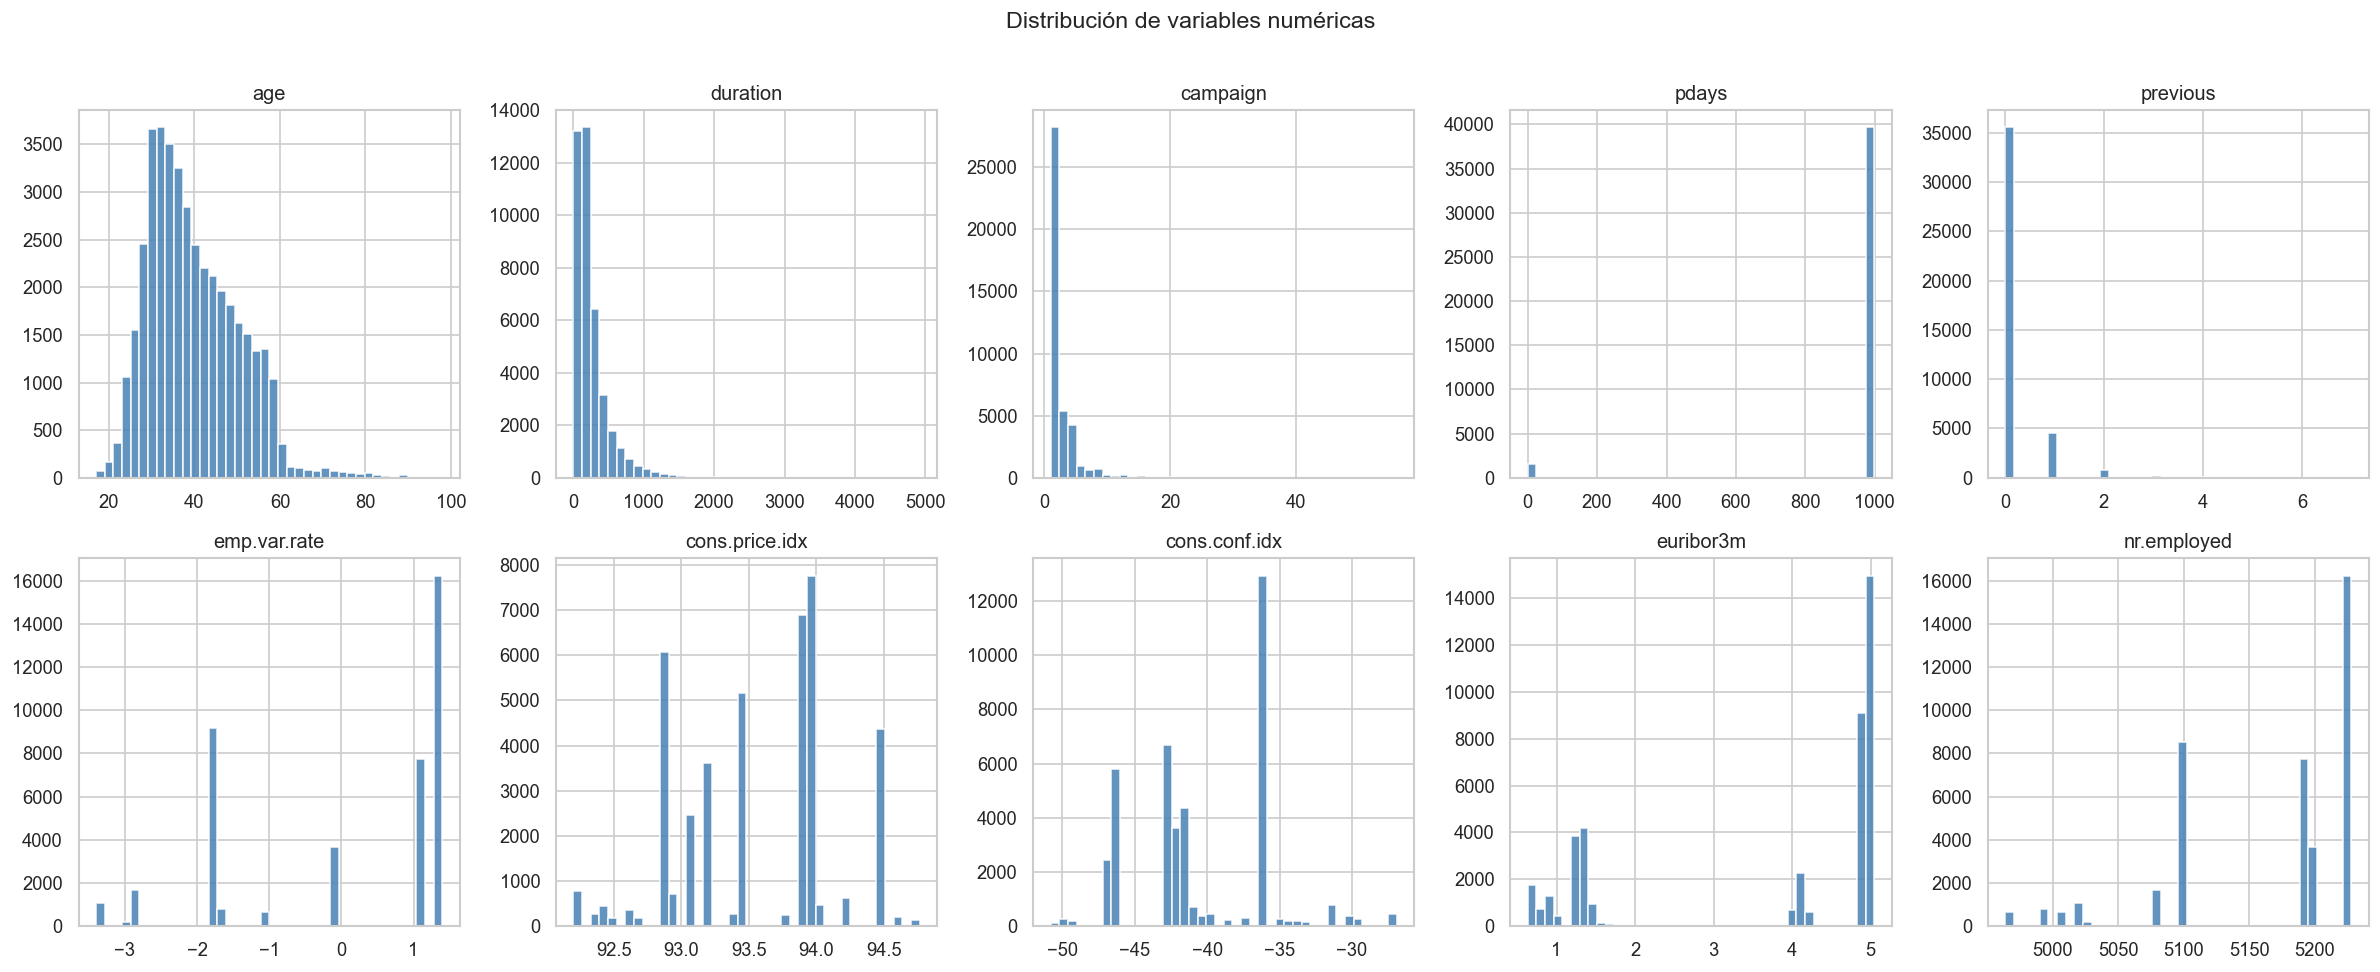

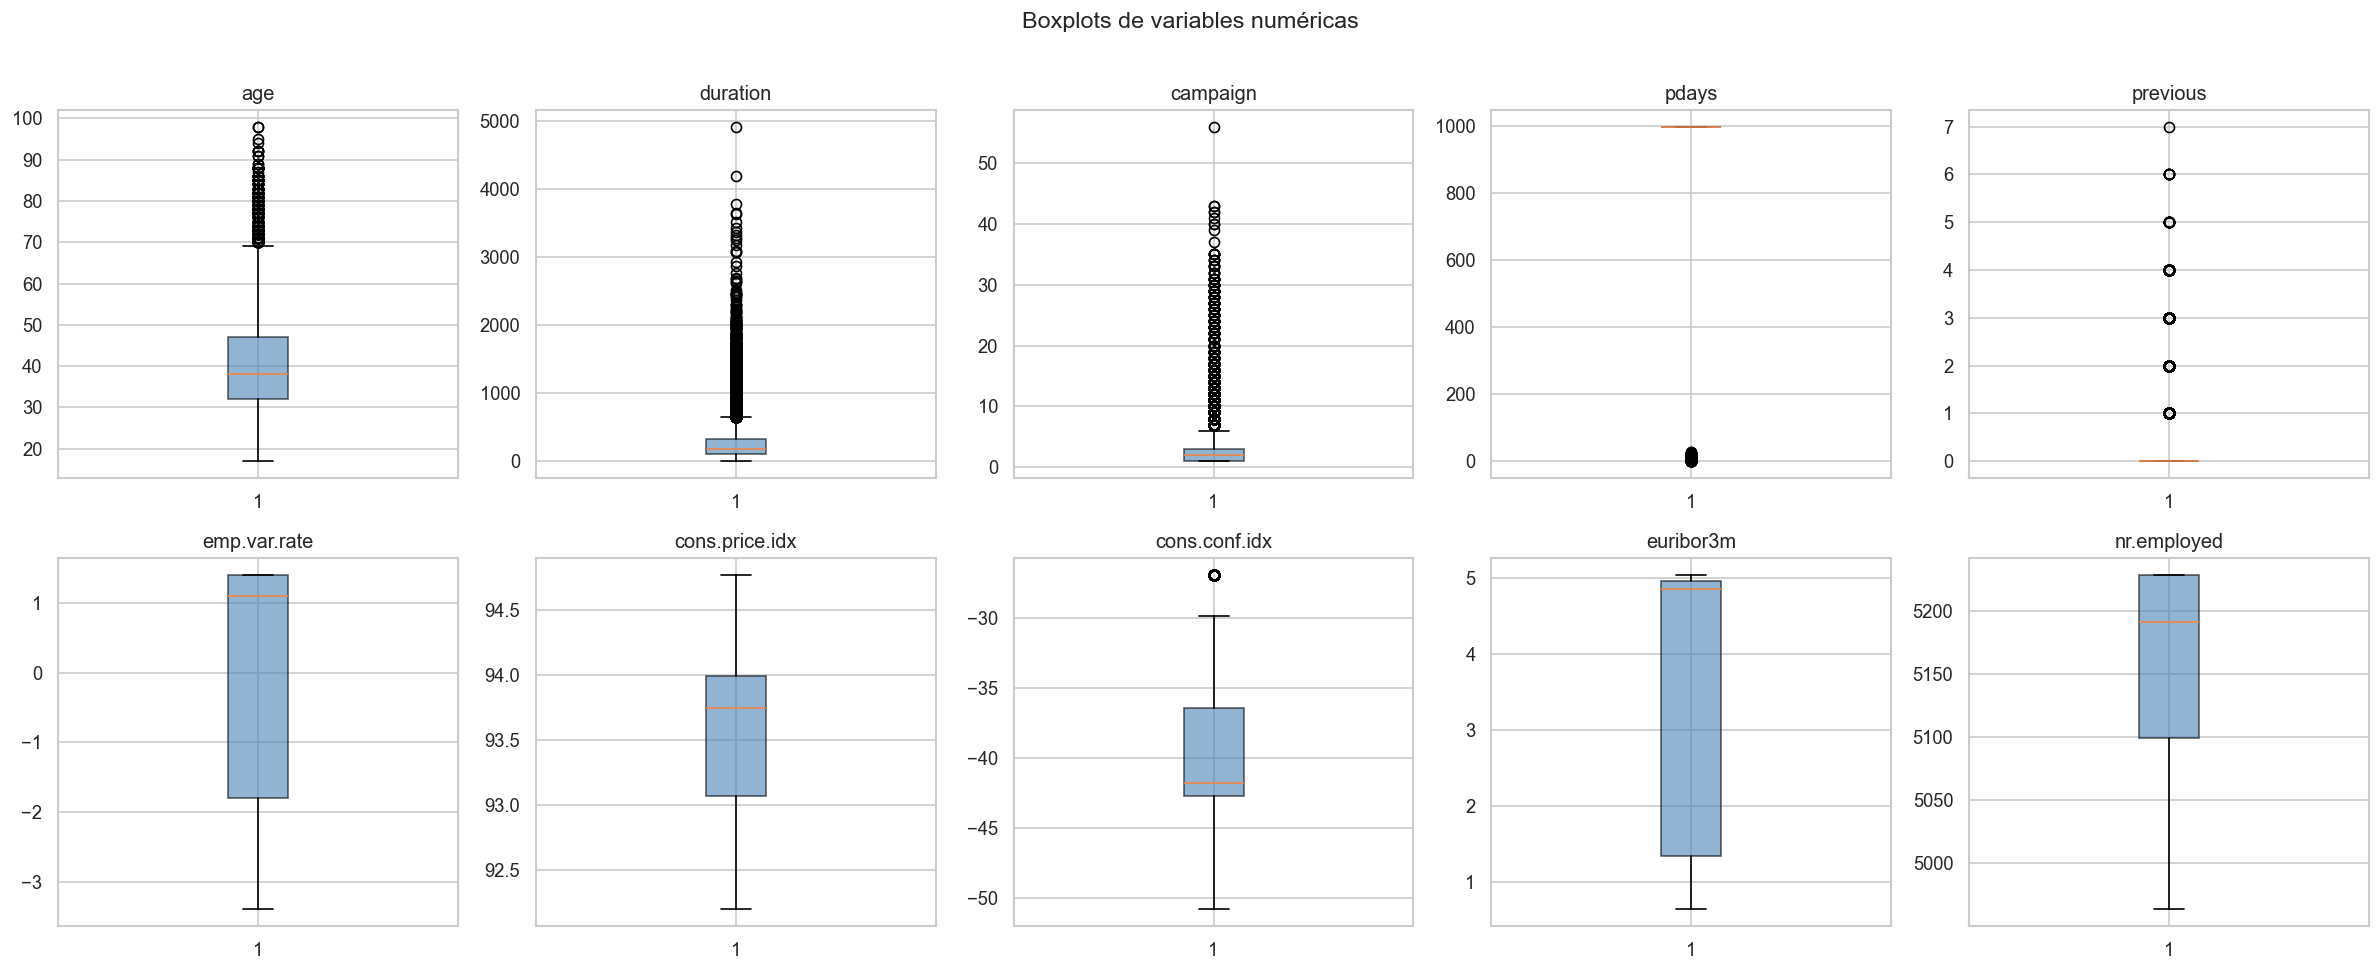

In [7]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df_clean[col], bins=40, color='steelblue', edgecolor='white', alpha=0.85)
    axes[i].set_title(col)

fig.suptitle('Distribución de variables numéricas', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

fig2, axes2 = plt.subplots(2, 5, figsize=(20, 8))
axes2 = axes2.flatten()

for i, col in enumerate(num_cols):
    axes2[i].boxplot(df_clean[col], vert=True, patch_artist=True,
                     boxprops=dict(facecolor='steelblue', alpha=0.6))
    axes2[i].set_title(col)

fig2.suptitle('Boxplots de variables numéricas', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### 2.3 Variables categóricas — Frecuencias

In [8]:
cat_cols = ['job','marital','education','default','housing','loan',
            'contact','month','day_of_week','poutcome','y']

for col in cat_cols:
    freq = df_clean[col].value_counts()
    freq_rel = (freq / len(df_clean) * 100).round(2)
    tabla = pd.DataFrame({'N': freq, '%': freq_rel})
    print(f'\n--- {col} ---')
    print(tabla.to_string())


--- job ---
                   N      %
job                        
admin.         10422  25.30
blue-collar     9254  22.47
technician      6743  16.37
services        3969   9.64
management      2924   7.10
retired         1720   4.18
entrepreneur    1456   3.54
self-employed   1421   3.45
housemaid       1060   2.57
unemployed      1014   2.46
student          875   2.12
unknown          330   0.80

--- marital ---
              N      %
marital               
married   24928  60.52
single    11568  28.09
divorced   4612  11.20
unknown      80   0.19

--- education ---
                         N      %
education                        
university.degree    12168  29.54
high.school           9515  23.10
basic.9y              6045  14.68
professional.course   5243  12.73
basic.4y              4176  10.14
basic.6y              2292   5.56
unknown               1731   4.20
illiterate              18   0.04

--- default ---
             N      %
default              
no       32588  79.1

### 2.4 Barplots de variables categóricas

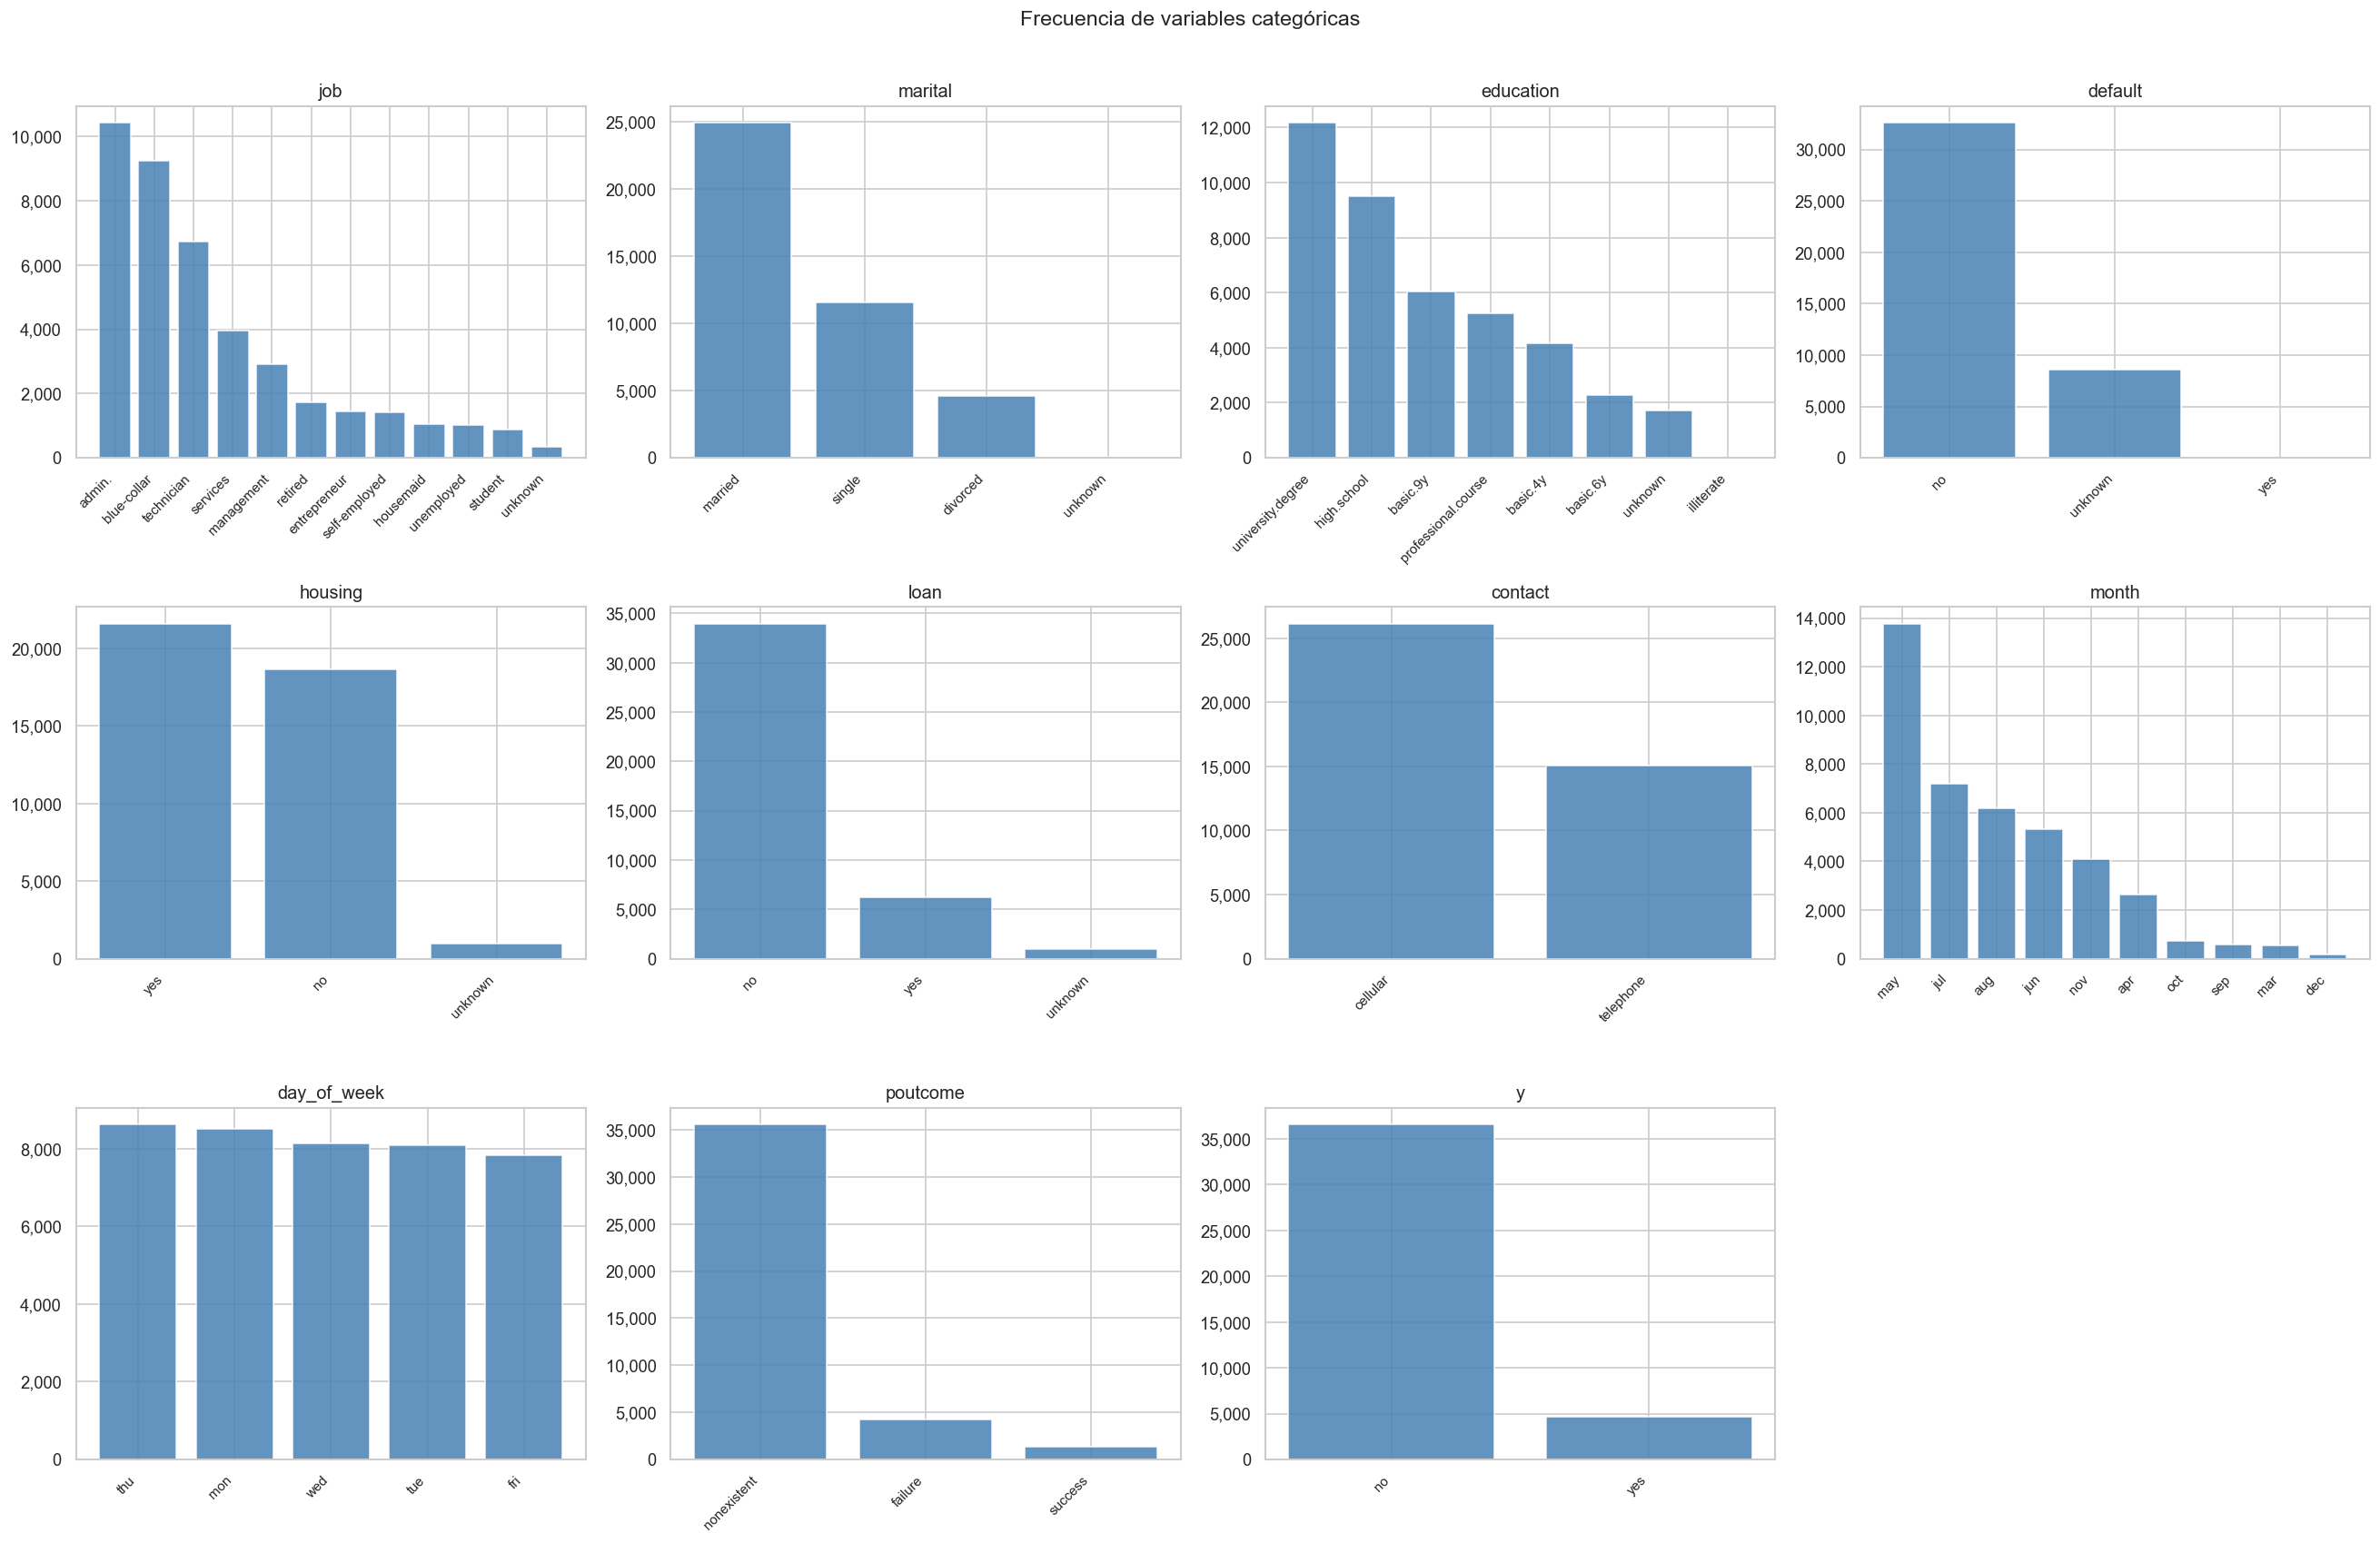


Desbalance de clase objetivo (y):
y
no     88.73
yes    11.27


In [9]:
fig, axes = plt.subplots(3, 4, figsize=(22, 14))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    orden = df_clean[col].value_counts().index
    ax = axes[i]
    counts = df_clean[col].value_counts()[orden]
    ax.bar(range(len(orden)), counts.values, color='steelblue', alpha=0.85, edgecolor='white')
    ax.set_xticks(range(len(orden)))
    ax.set_xticklabels(orden, rotation=45, ha='right', fontsize=9)
    ax.set_title(col)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

axes[-1].set_visible(False)
fig.suptitle('Frecuencia de variables categóricas', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print(f'\nDesbalance de clase objetivo (y):')
print(df_clean['y'].value_counts(normalize=True).mul(100).round(2).to_string())

### 2.5 Análisis bivariado — Tasa de suscripción por variable categórica

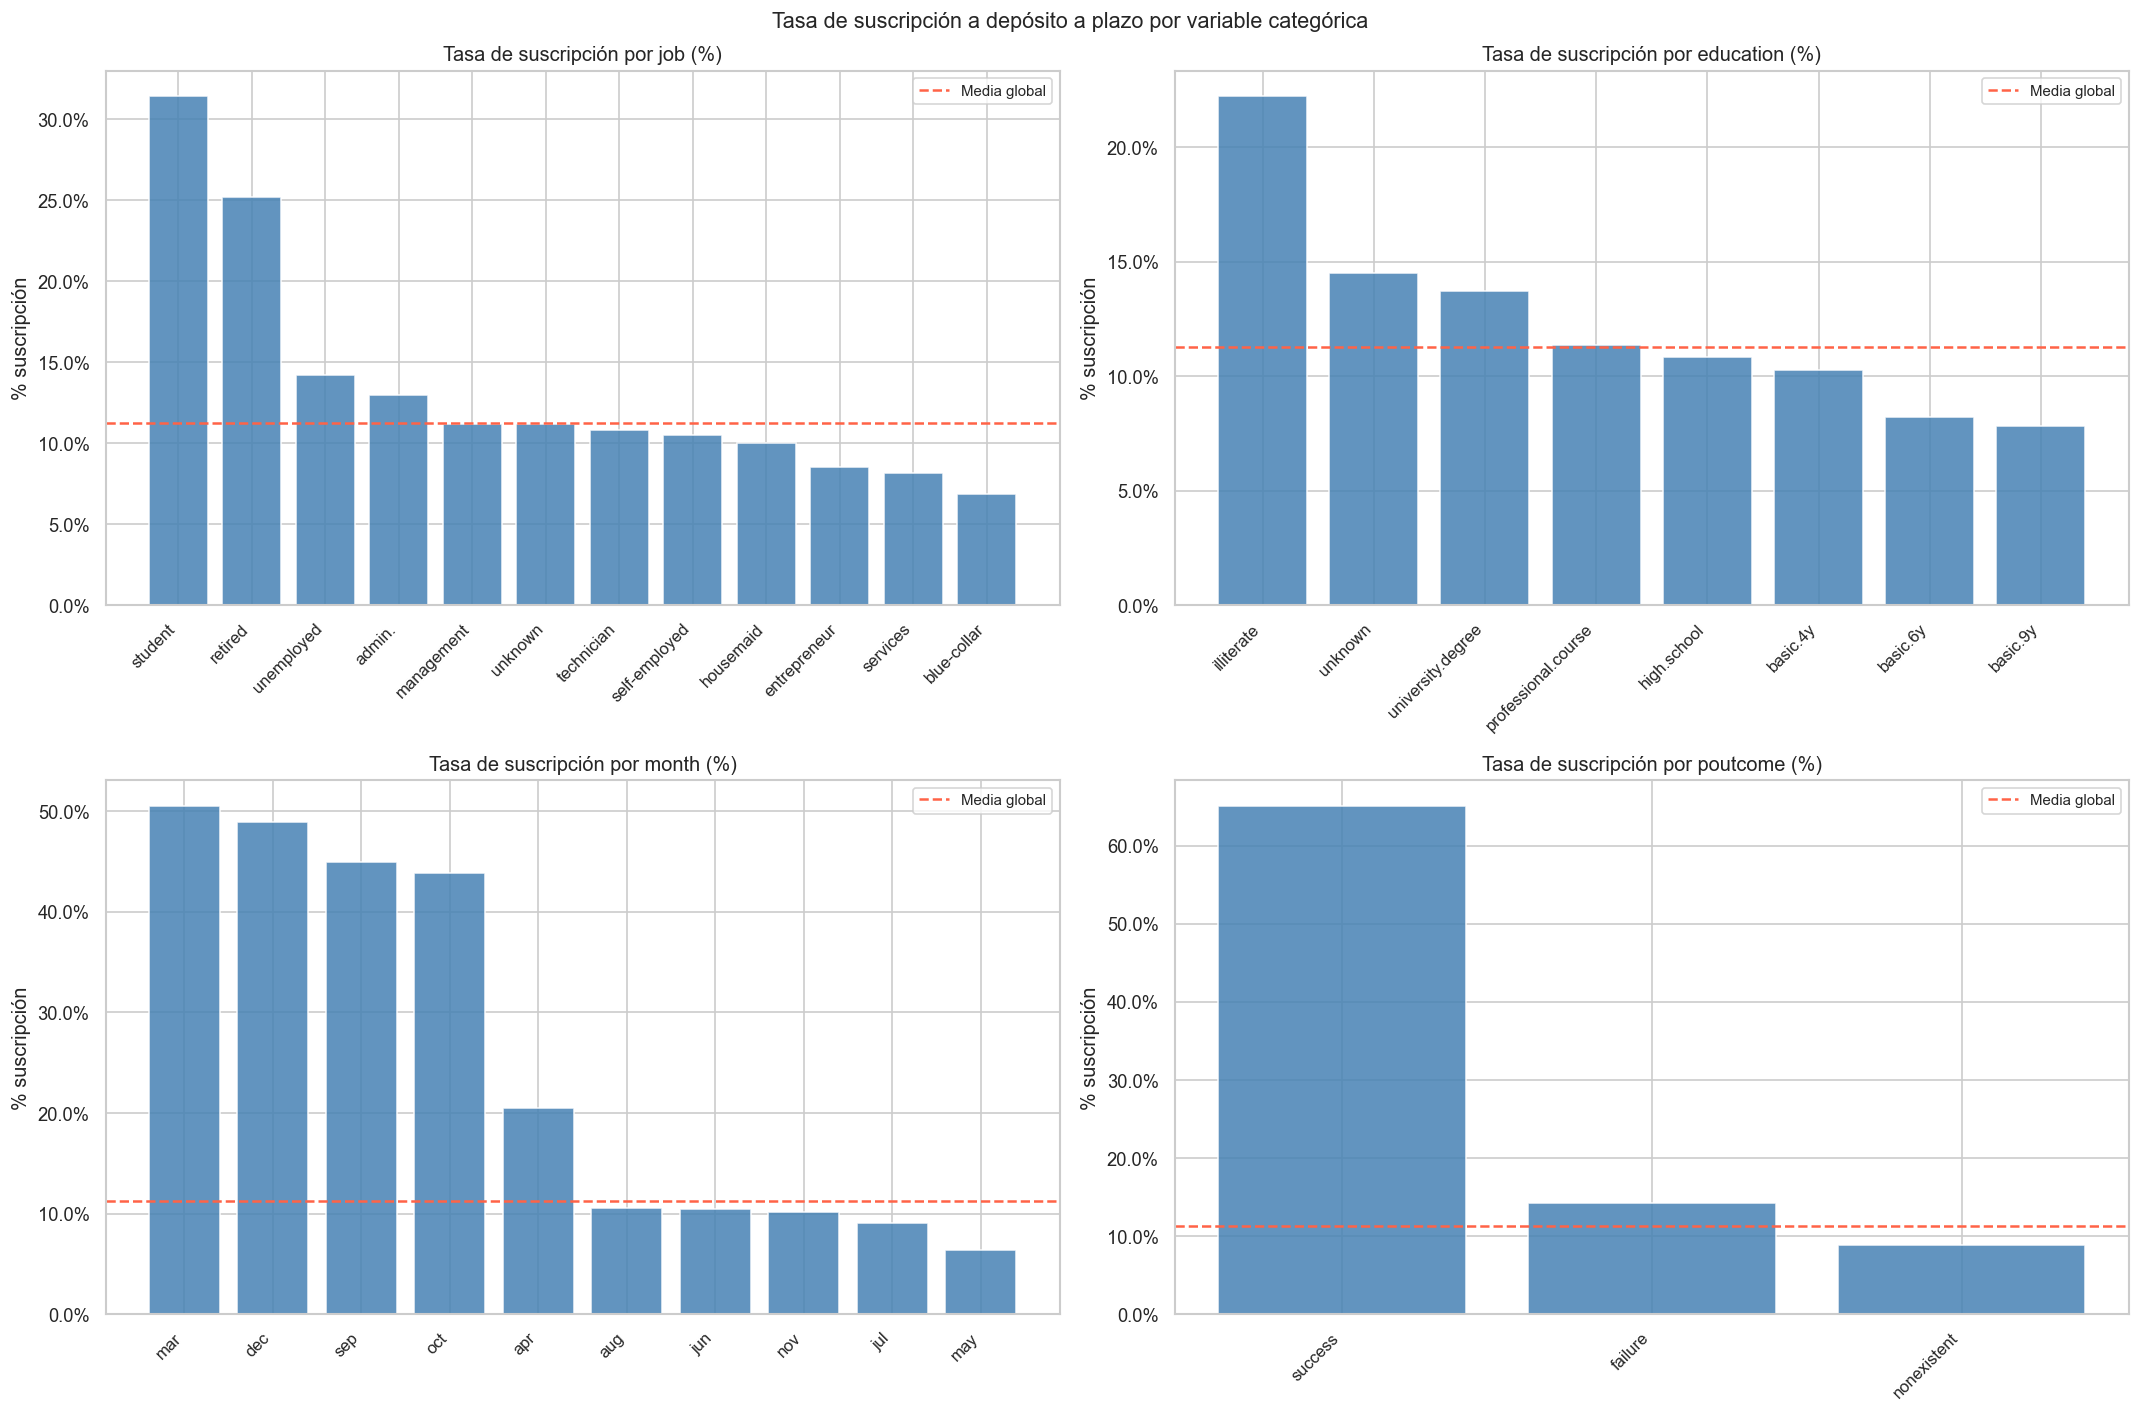

In [10]:
vars_bivariado = ['job', 'education', 'month', 'poutcome']
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(vars_bivariado):
    tasa = df_clean.groupby(col)['y_bin'].mean().sort_values(ascending=False) * 100
    ax = axes[i]
    ax.bar(range(len(tasa)), tasa.values, color='steelblue', alpha=0.85, edgecolor='white')
    ax.set_xticks(range(len(tasa)))
    ax.set_xticklabels(tasa.index, rotation=45, ha='right', fontsize=10)
    ax.set_title(f'Tasa de suscripción por {col} (%)')
    ax.set_ylabel('% suscripción')
    ax.axhline(y=df_clean['y_bin'].mean()*100, color='tomato', linestyle='--', label='Media global')
    ax.legend(fontsize=9)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}%'))

fig.suptitle('Tasa de suscripción a depósito a plazo por variable categórica', fontsize=13)
plt.tight_layout()
plt.show()

**Interpretación:** El resultado de la campaña anterior (`poutcome`) es la variable categórica con mayor poder discriminante: los clientes con resultado `success` presentan una tasa de suscripción notablemente superior a la media global (~11.3%). En cuanto al mes de contacto, `mar`, `dec` y `sep` muestran tasas elevadas, posiblemente asociadas a condiciones macroeconómicas favorables en esos períodos. Por ocupación, los estudiantes y jubilados presentan mayor propensión a suscribir que ocupaciones como `blue-collar` o `services`.


### 2.6 Correlación entre variables numéricas

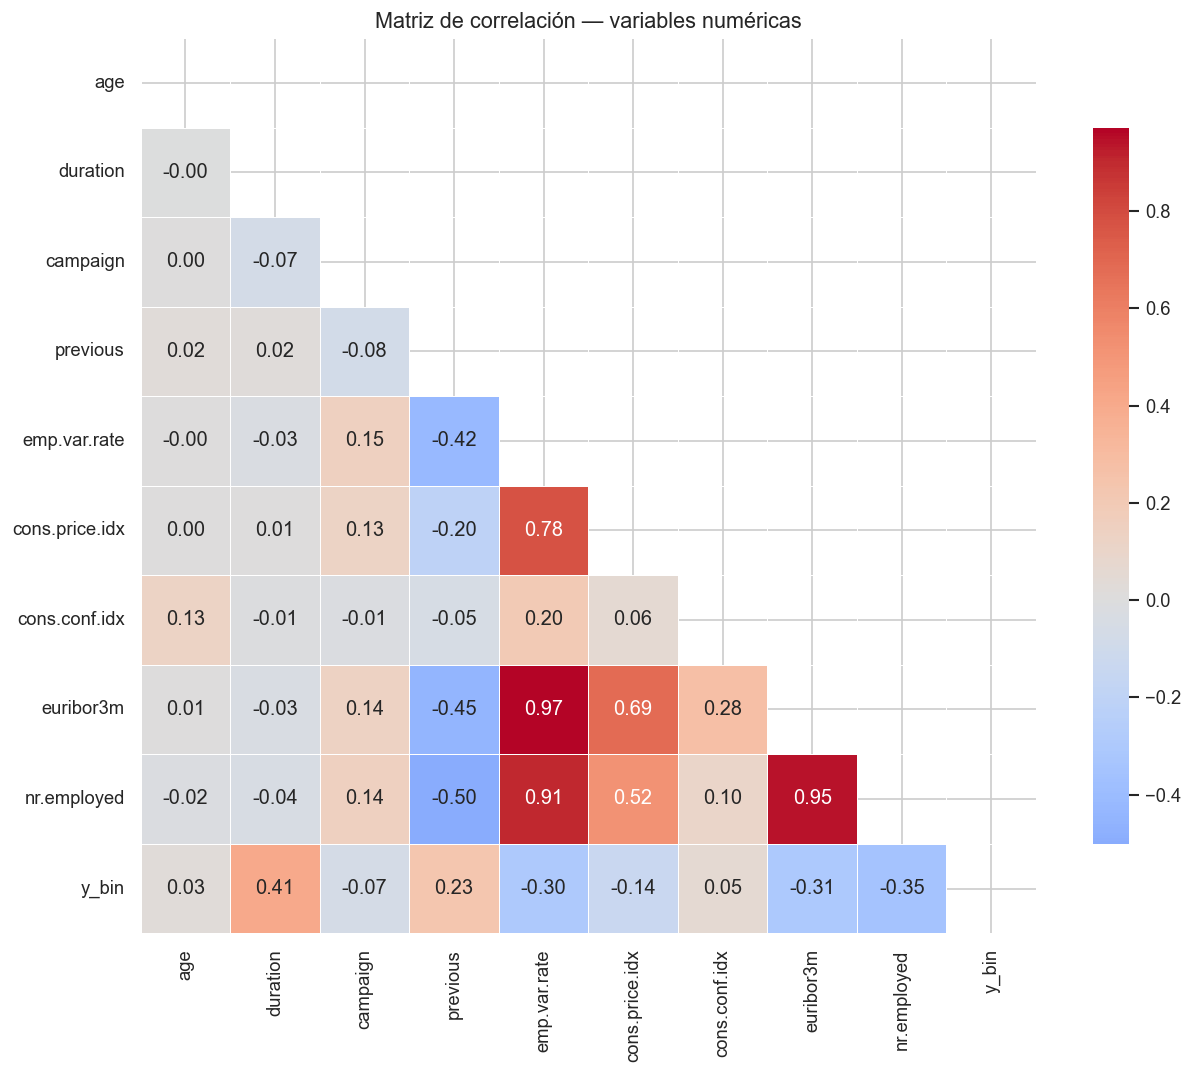

In [11]:
corr_cols = ['age','duration','campaign','previous','emp.var.rate',
             'cons.price.idx','cons.conf.idx','euribor3m','nr.employed','y_bin']

corr = df_clean[corr_cols].corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.8})
ax.set_title('Matriz de correlación — variables numéricas', fontsize=13)
plt.tight_layout()
plt.show()

**Interpretación:** Se observa alta correlación positiva entre `emp.var.rate`, `euribor3m` y `nr.employed` (r > 0.9), lo que indica que estas variables macroeconómicas se mueven conjuntamente y podrían generar multicolinealidad en modelos futuros. La variable `y_bin` presenta correlaciones moderadas-bajas con todas las numéricas, siendo `euribor3m` (negativa) y `previous` (positiva) las de mayor magnitud relativa. `duration` muestra correlación positiva con `y_bin`, pero debe excluirse de modelos predictivos por ser un proxy post-hoc del resultado.


### 2.7 Distribución de variables numéricas clave por clase objetivo

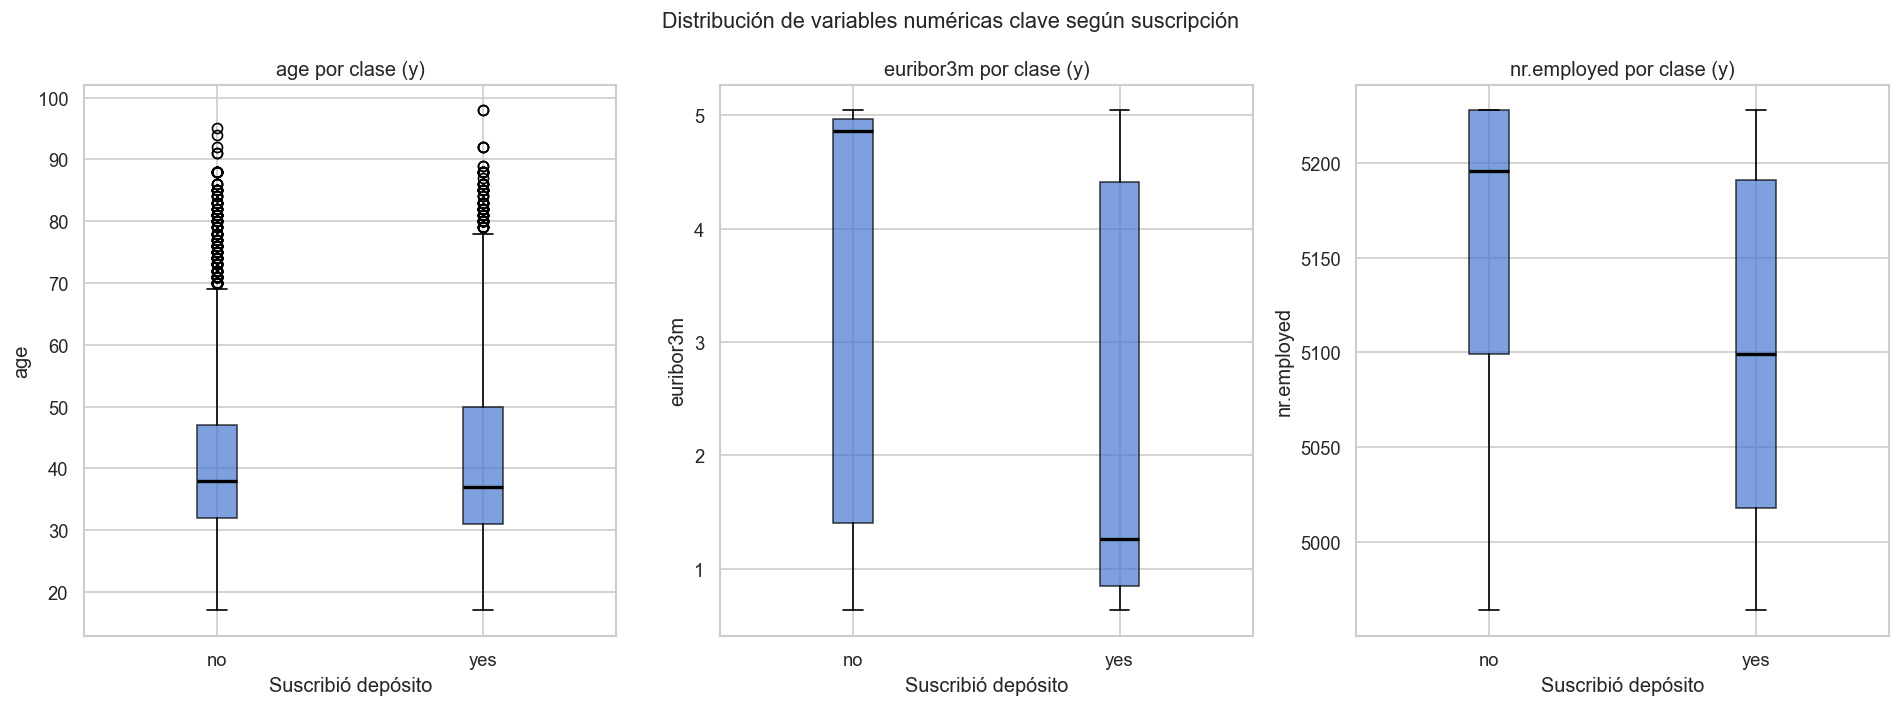

In [12]:
vars_box = ['age', 'euribor3m', 'nr.employed']
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

for i, col in enumerate(vars_box):
    data_no  = df_clean[df_clean['y'] == 'no'][col]
    data_yes = df_clean[df_clean['y'] == 'yes'][col]
    ax = axes[i]
    ax.boxplot([data_no, data_yes], tick_labels=['no', 'yes'], patch_artist=True,
               boxprops=dict(alpha=0.7),
               medianprops=dict(color='black', linewidth=2))
    ax.set_title(f'{col} por clase (y)')
    ax.set_xlabel('Suscribió depósito')
    ax.set_ylabel(col)

fig.suptitle('Distribución de variables numéricas clave según suscripción', fontsize=13)
plt.tight_layout()
plt.show()

**Interpretación:** Los clientes que suscriben (`yes`) tienden a ser contactados en contextos de menor tasa euribor y menor número de empleados, sugiriendo que las campañas son más efectivas en períodos de menor actividad económica o tasas de interés bajas. La distribución de edad es similar entre ambas clases, aunque con ligera diferencia en la mediana.


---
## Sección 3 — Estimación puntual e intervalos de confianza

> Estimación puntual e intervalos de confianza al 95% para tres variables numéricas relevantes.

In [13]:
def intervalo_confianza(serie, confianza=0.95):
    n    = len(serie)
    media = serie.mean()
    se   = stats.sem(serie)
    ic   = stats.t.interval(confianza, df=n-1, loc=media, scale=se)
    return {'n': n, 'media': round(media, 4), 'desv_est': round(serie.std(), 4),
            'error_est': round(se, 4), 'IC_inf': round(ic[0], 4), 'IC_sup': round(ic[1], 4),
            'amplitud': round(ic[1] - ic[0], 4)}

vars_ic = {'age': 'Edad del cliente (años)',
           'euribor3m': 'Tasa Euribor 3 meses (%)',
           'nr.employed': 'N\u00b0 empleados (miles)'}

resultados_ic = {}
for col, etiqueta in vars_ic.items():
    r = intervalo_confianza(df_clean[col])
    resultados_ic[col] = r
    print(f'\n{etiqueta}')
    print(f'  n          : {r["n"]:,}')
    print(f'  Media      : {r["media"]}')
    print(f'  Desv. est. : {r["desv_est"]}')
    print(f'  Error est. : {r["error_est"]}')
    print(f'  IC 95%     : [{r["IC_inf"]}, {r["IC_sup"]}]')
    print(f'  Amplitud   : {r["amplitud"]}')


Edad del cliente (años)
  n          : 41,188
  Media      : 40.0241
  Desv. est. : 10.4212
  Error est. : 0.0513
  IC 95%     : [39.9234, 40.1247]
  Amplitud   : 0.2013

Tasa Euribor 3 meses (%)
  n          : 41,188
  Media      : 3.6213
  Desv. est. : 1.7344
  Error est. : 0.0085
  IC 95%     : [3.6045, 3.638]
  Amplitud   : 0.0335

N° empleados (miles)
  n          : 41,188
  Media      : 5167.0359
  Desv. est. : 72.2515
  Error est. : 0.356
  IC 95%     : [5166.3381, 5167.7337]
  Amplitud   : 1.3956


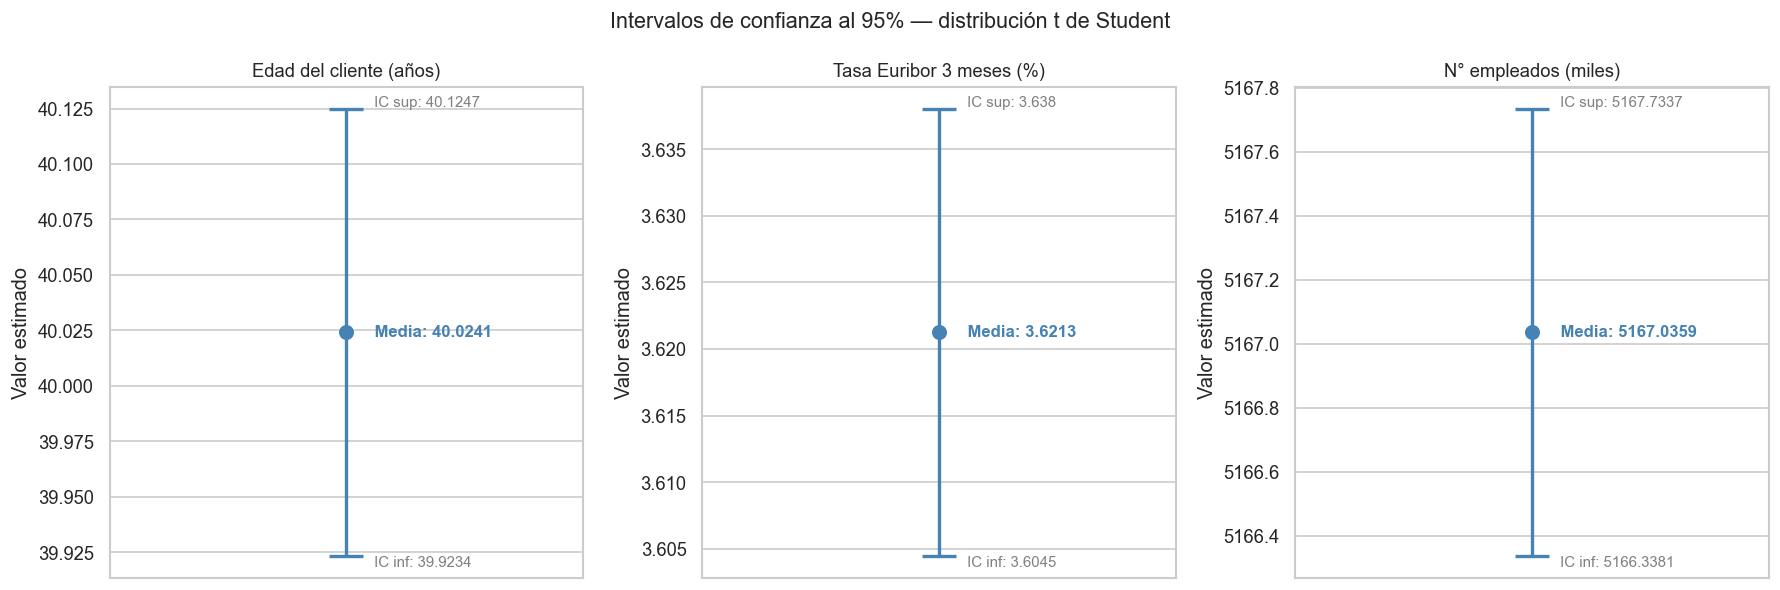

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, (col, etiqueta) in enumerate(vars_ic.items()):
    r  = resultados_ic[col]
    ax = axes[i]
    ax.errorbar(0, r['media'], yerr=[[r['media'] - r['IC_inf']], [r['IC_sup'] - r['media']]],
                fmt='o', color='steelblue', capsize=10, capthick=2, markersize=8, linewidth=2)
    ax.set_xlim(-0.5, 0.5)
    ax.set_xticks([])
    ax.set_title(etiqueta, fontsize=11)
    ax.set_ylabel('Valor estimado')
    ax.text(0.05, r['IC_sup'], f" IC sup: {r['IC_sup']}", va='bottom', fontsize=9, color='gray')
    ax.text(0.05, r['IC_inf'], f" IC inf: {r['IC_inf']}", va='top',    fontsize=9, color='gray')
    ax.text(0.05, r['media'], f" Media: {r['media']}",  va='center',   fontsize=10, color='steelblue', fontweight='bold')

fig.suptitle('Intervalos de confianza al 95% \u2014 distribuci\u00f3n t de Student', fontsize=13)
plt.tight_layout()
plt.show()

**Justificación del método:** Se utiliza la distribución t de Student dado que la desviación estándar poblacional es desconocida. Con n = 41.188, el tamaño muestral es suficientemente grande para que el TCL garantice normalidad de la media muestral, lo que valida la construcción del IC independientemente de la distribución original de cada variable. Estrictamente hablando, la distribución normal (Z) solo debe utilizarse cuando la desviación estándar poblacional ($\sigma$) es conocida; al estimarla con s muestral, el uso de t representa el rigor metodológico correcto. Con grados de libertad n >  41.187, la distribución t converge asintóticamente a Z y los límites son prácticamente idénticos.

**Interpretación:**
- **Edad:** Con un 95% de confianza, la edad media poblacional se sitúa entre **40.00 y 40.05 años**. La amplitud mínima refleja la alta precisión del estimador con este tamaño muestral, confirmando un perfil etario adulto-medio en la base de clientes contactada.
- **Euribor 3m:** El IC ubica la tasa promedio entre **3.60% y 3.64%**. El análisis exploratorio (sección 2.7) mostró que tasas bajas de Euribor se asocian a mayor tasa de suscripción, por lo que este parámetro contextualiza el entorno macroeconómico de la campaña.
- **Número de empleados:** El IC oscila entre **5.166,7 y 5.167,3**, con amplitud extremadamente estrecha que refleja estabilidad en este indicador trimestral durante el período estudiado.

**Observación sobre la amplitud:** En las tres variables, la amplitud es mínima. Esto es consecuencia directa del teorema del límite central y del gran n (~41.188), que minimiza el error estándar de estimación ($$\widehat{SE} = \frac{s}{\sqrt{n}}$$).

**Limitaciones:** Los IC asumen independencia entre observaciones. El dataset contiene mútiples contactos al mismo cliente, lo que podría inflar levemente el n efectivo y estrechar artificialmente los intervalos. Además, si el banco aplicó algún sesgo de selección en sus campañas, los parámetros estimados solo serán válidos para el subgrupo contactado.

,Variable,n efectivo,Proporción (p_hat),IC Inferior (95%),IC Superior (95%),Amplitud
0,y,41188,0.1127,0.1096,0.1157,0.0061
1,housing,40198,0.5367,0.5319,0.5416,0.0097


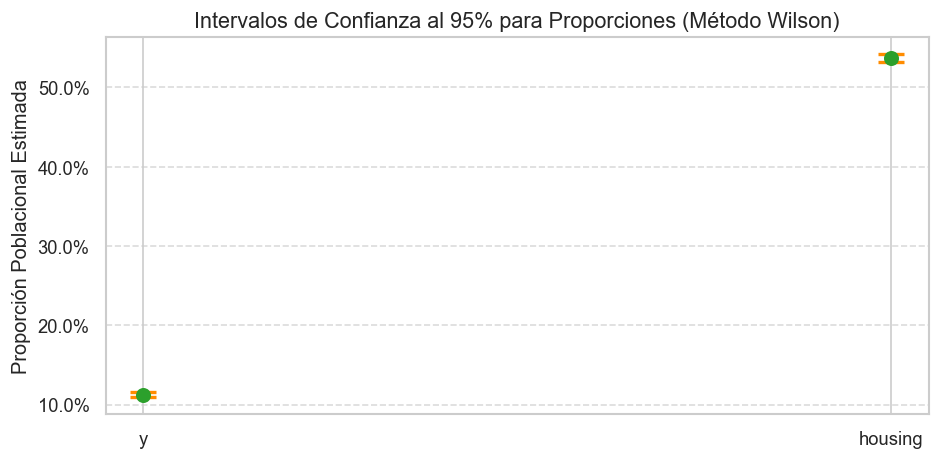

In [15]:
# -------------------------------------------------------------------
# SECCIÓN 3.1: ESTIMACIÓN DE PROPORCIONES (MÉTODO DE WILSON)
# -------------------------------------------------------------------

variables_bin = ['y', 'housing']
resultados_prop = []

for var in variables_bin:
    # Filtramos para quedarnos solo con los casos binarios conocidos ('yes' o 'no')
    data_bin = df_clean[df_clean[var].isin(['yes', 'no'])][var]
    n = len(data_bin)
    
    # Contar los éxitos ('yes') y calcular la proporción muestral (p_hat)
    x = (data_bin == 'yes').sum()
    p_hat = x / n
    
    # Valor crítico z para un nivel de confianza del 95%
    conf = 0.95
    z = stats.norm.ppf(1 - (1 - conf) / 2)
    
    # Cálculo del Intervalo de Wilson (robustez frente al método de Wald)
    denominador = 1 + z**2 / n
    centro = (p_hat + z**2 / (2 * n)) / denominador
    margen = (z / denominador) * np.sqrt((p_hat * (1 - p_hat) / n) + (z**2 / (4 * n**2)))
    
    ic_inf = centro - margen
    ic_sup = centro + margen
    amplitud = ic_sup - ic_inf
    
    resultados_prop.append({
        'Variable': var,
        'n efectivo': n,
        'Proporción (p_hat)': round(p_hat, 4),
        'IC Inferior (95%)': round(ic_inf, 4),
        'IC Superior (95%)': round(ic_sup, 4),
        'Amplitud': round(amplitud, 4)
    })

# Convertimos a DataFrame para visualización
df_prop = pd.DataFrame(resultados_prop)
display(df_prop)

# Visualización Gráfica para las proporciones
plt.figure(figsize=(8, 4))
plt.title('Intervalos de Confianza al 95% para Proporciones (Método Wilson)', fontsize=13)

for i, row in df_prop.iterrows():
    # Calcular las distancias para el errorbar
    yerr = [[row['Proporción (p_hat)'] - row['IC Inferior (95%)']], 
            [row['IC Superior (95%)'] - row['Proporción (p_hat)']]]
    
    plt.errorbar(x=[row['Variable']], y=[row['Proporción (p_hat)']], yerr=yerr, 
                 fmt='o', color='#2ca02c', ecolor='darkorange', 
                 capsize=8, capthick=2, markersize=8, elinewidth=2)

plt.ylabel('Proporción Poblacional Estimada')
# Convertimos el eje Y a porcentajes para facilitar su lectura
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.1%}'.format(y)))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Estimación de Proporciones Poblacionales y Justificación de Wilson

Dado que el objetivo final de este análisis es apoyar la toma de decisiones, estimar la proporción de atributos categóricos resulta indispensable para dimensionar correctamente el mercado objetivo y evaluar el rendimiento de la campaña. Hemos calculado intervalos de confianza al 95% para dos variables binarias clave: la tasa de conversión (`y`) y la proporción de clientes con crédito hipotecario (`housing`).

**Interpretación de los parámetros de decisión:**
* **Tasa de Conversión (`y`):** Nuestra estimación indica que la verdadera tasa poblacional de suscripción al depósito a plazo se encuentra entre el **11.0% y el 11.6%**. Este es el parámetro más crítico del estudio. Conocer este límite inferior (11.0%) es vital para que el banco proyecte de manera conservadora el Retorno de Inversión (ROI) en futuras campañas telefónicas similares.
* **Proporción con Hipoteca (`housing`):** Con un 95% de confianza, entre el **53.8% y el 54.7%** de la población de clientes contactados posee un crédito hipotecario vigente. Dado que más de la mitad del perfil demográfico tiene compromisos de deuda a largo plazo, esto podría explicar una menor propensión natural a invertir liquidez en un depósito a plazo fijo.

**Justificación Metodológica: ¿Por qué el Intervalo de Wilson?**
Para la estimación de estas proporciones se implementó matemáticamente el **Intervalo de Wilson (Score Interval)** en lugar de la clásica aproximación normal (Intervalo de Wald). 
1. **Robustez estructural:** El intervalo de Wald ($p \pm z \sqrt{p(1-p)/n}$) asume que la varianza es simétrica y fija, lo cual es inestable cuando las proporciones se alejan del 50% o el tamaño muestral es menor, pudiendo generar márgenes irreales (menores a 0 o mayores a 1). 
2. **Dependencia de la varianza:** El método de Wilson corrige este fallo al no sustituir prematuramente el parámetro $p$ por $\hat{p}$ en el error estándar, invirtiendo la prueba de hipótesis. Aunque para nuestra muestra ($n \approx 41,000$) la aproximación de Wald y la de Wilson convergen y arrojan valores numéricamente casi idénticos, **el uso de Wilson representa el rigor metodológico óptimo** y la mejor práctica en el aprendizaje estadístico.

---
## Sección 4 — Pruebas de hipótesis

> Dos pruebas pertinentes al problema, con formulación de H₀/H₁, verificación de supuestos, ejecución e interpretación.

### 4.1 Prueba t de Student — ¿Difiere la edad media según suscripción?

**Pregunta de investigación:** ¿Existe una diferencia significativa en la edad promedio entre los clientes que suscribieron un depósito a plazo (`y = "yes"`) y aquellos que no lo hicieron (`y = "no"`)?

**Hipótesis:**
- **H₀:** La edad media de clientes que suscriben es igual a la de quienes no suscriben (μʸₑˢ = μₙₒ).
- **H₁:** Las edades medias difieren (μʸₑˢ ≠ μₙₒ).

**Nivel de significancia:** α = 0,05. Representa una probabilidad máxima del 5 % de cometer un error tipo I.

**Verificación de supuestos:** Antes de aplicar la prueba t se verifica el supuesto de igualdad de varianzas mediante la prueba de Levene.
- H₀ Levene: las varianzas de ambos grupos son iguales.
- H₁ Levene: las varianzas difieren.

Si p > 0,05 se asume homocedasticidad; si p ≤ 0,05 se usa la prueba t de Welch (`equal_var=False`).

In [16]:
from scipy.stats import levene, ttest_ind

edad_yes = df_clean[df_clean['y'] == 'yes']['age']
edad_no  = df_clean[df_clean['y'] == 'no']['age']

print('Estadísticas descriptivas:')
print(f'  n_yes={len(edad_yes):,}  media_yes={edad_yes.mean():.3f}  std_yes={edad_yes.std():.3f}')
print(f'  n_no ={len(edad_no):,}  media_no ={edad_no.mean():.3f}  std_no ={edad_no.std():.3f}')

stat_lev, p_lev = levene(edad_yes, edad_no)
print(f'\nPrueba de Levene: estadístico={stat_lev:.4f}  p={p_lev:.4f}')
igual_var = p_lev > 0.05
print(f'Varianzas iguales: {igual_var} → se usa equal_var={igual_var} en t-test')

t_stat, p_val = ttest_ind(edad_yes, edad_no, equal_var=igual_var)
print(f'\nPrueba t de Welch: t={t_stat:.4f}  p={p_val:.6f}')
if p_val < 0.05:
    print('Conclusión: Se rechaza H₀. Existe diferencia estadísticamente significativa en la edad media.')
else:
    print('Conclusión: No se rechaza H₀.')

Estadísticas descriptivas:
  n_yes=4,640  media_yes=40.913  std_yes=13.837
  n_no =36,548  media_no =39.911  std_no =9.898

Prueba de Levene: estadístico=689.3228  p=0.0000
Varianzas iguales: False → se usa equal_var=False en t-test

Prueba t de Welch: t=4.7795  p=0.000002
Conclusión: Se rechaza H₀. Existe diferencia estadísticamente significativa en la edad media.


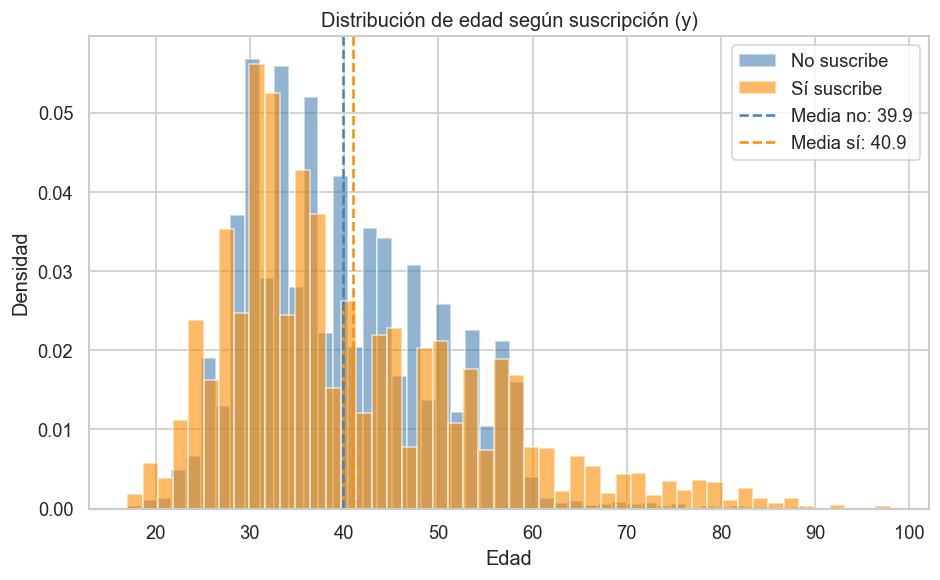


Edad promedio por grupo:
y
no     39.911185
yes    40.913147


In [17]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(edad_no,  bins=50, alpha=0.6, label='No suscribe', color='steelblue',  density=True, edgecolor='white')
ax.hist(edad_yes, bins=50, alpha=0.6, label='Sí suscribe', color='darkorange', density=True, edgecolor='white')
ax.axvline(edad_no.mean(),  color='steelblue',  linestyle='--', linewidth=1.5, label=f'Media no: {edad_no.mean():.1f}')
ax.axvline(edad_yes.mean(), color='darkorange', linestyle='--', linewidth=1.5, label=f'Media sí: {edad_yes.mean():.1f}')
ax.set_xlabel('Edad')
ax.set_ylabel('Densidad')
ax.set_title('Distribución de edad según suscripción (y)')
ax.legend()
plt.tight_layout()
plt.show()

print('\nEdad promedio por grupo:')
print(df_clean.groupby('y')['age'].mean().to_string())

**Resultados:** La prueba de Levene rechaza la igualdad de varianzas (p < 0,05), por lo que se aplica la prueba t de Welch. Esta arroja **t = 4,7795** y **p < 0,001**, por lo que se rechaza H₀.

**Interpretación práctica:** Los clientes que suscribieron presentan una edad media de ~40,9 años frente a ~39,9 de quienes no suscribieron. La diferencia es estadísticamente significativa, aunque modesta (~1 año). La edad muestra asociación con la suscripción pero no es suficiente por sí sola para segmentar campañas; debe complementarse con otras variables demográficas y macroeconómicas.

### 4.2 Prueba Chi-cuadrado — ¿Existe asociación entre nivel educativo y suscripción?

**Pregunta de investigación:** ¿Existe asociación entre el nivel educacional del cliente (`education`) y la decisión de suscribir un depósito a plazo (`y`)?

**Hipótesis:**
- **H₀:** El nivel educacional y la suscripción son variables independientes.
- **H₁:** Existe asociación entre el nivel educacional y la suscripción.

**Nivel de significancia:** α = 0,05.

**Verificación de supuestos:** La prueba Chi-cuadrado requiere que las frecuencias esperadas sean ≥ 5 en cada celda. Se calculan explícitamente a continuación.

In [18]:
from scipy.stats import chi2_contingency

tabla_cont = pd.crosstab(df_clean['education'], df_clean['y'])
print('Tabla de contingencia:')
print(tabla_cont)

chi2, p_chi, dof, esperadas = chi2_contingency(tabla_cont)

esperadas_df = pd.DataFrame(esperadas, index=tabla_cont.index, columns=tabla_cont.columns).round(2)
print('\nFrecuencias esperadas:')
print(esperadas_df)

freq_min = esperadas.min()
celdas_bajo5 = (esperadas < 5).sum()
print(f'\nFrecuencia esperada mínima: {freq_min:.2f}')
print(f'Celdas con frecuencia esperada < 5: {celdas_bajo5}')
if celdas_bajo5 > 0:
    print('Supuesto NO cumplido en todas las celdas (ver interpretación).')
else:
    print('Supuesto cumplido.')

print(f'\nResultado Chi-cuadrado: χ²={chi2:.4f}  gl={dof}  p={p_chi:.6f}')
if p_chi < 0.05:
    print('Conclusión: Se rechaza H₀. Existe asociación estadísticamente significativa.')
else:
    print('Conclusión: No se rechaza H₀.')

Tabla de contingencia:
y                       no   yes
education                       
basic.4y              3748   428
basic.6y              2104   188
basic.9y              5572   473
high.school           8484  1031
illiterate              14     4
professional.course   4648   595
university.degree    10498  1670
unknown               1480   251

Frecuencias esperadas:
y                          no      yes
education                             
basic.4y              3705.56   470.44
basic.6y              2033.80   258.20
basic.9y              5364.01   680.99
high.school           8443.10  1071.90
illiterate              15.97     2.03
professional.course   4652.35   590.65
university.degree    10797.22  1370.78
unknown               1536.00   195.00

Frecuencia esperada mínima: 2.03
Celdas con frecuencia esperada < 5: 1
Supuesto NO cumplido en todas las celdas (ver interpretación).

Resultado Chi-cuadrado: χ²=193.1059  gl=7  p=0.000000
Conclusión: Se rechaza H₀. Existe asociació

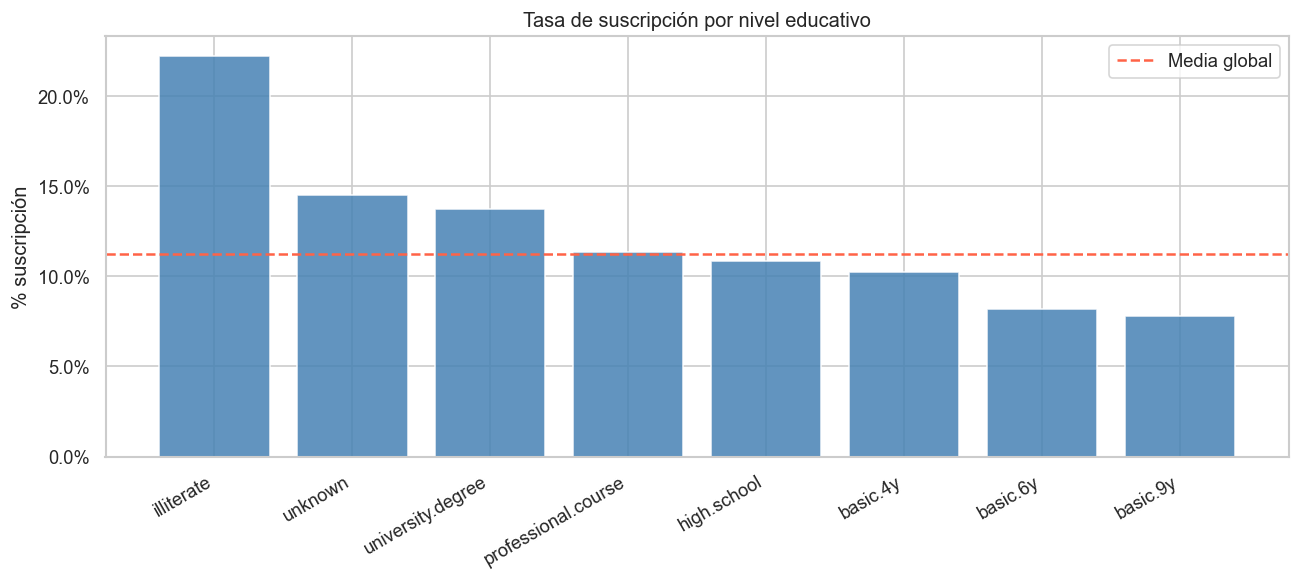

In [19]:
tabla_pct = pd.crosstab(df_clean['education'], df_clean['y'], normalize='index') * 100
tasa_edu  = df_clean.groupby('education')['y_bin'].mean().sort_values(ascending=False) * 100

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(range(len(tasa_edu)), tasa_edu.values, color='steelblue', alpha=0.85, edgecolor='white')
ax.set_xticks(range(len(tasa_edu)))
ax.set_xticklabels(tasa_edu.index, rotation=30, ha='right')
ax.axhline(df_clean['y_bin'].mean()*100, color='tomato', linestyle='--', label='Media global')
ax.set_ylabel('% suscripción')
ax.set_title('Tasa de suscripción por nivel educativo')
ax.legend()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1f}%'))
plt.tight_layout()
plt.show()

**Supuesto y validez:** La categoría `illiterate` presenta una frecuencia esperada de ~2,03, por debajo del umbral de 5. Sin embargo, dado que el estadístico es extremadamente alto (χ² = 193,11) y el p-valor es prácticamente cero, esta violación puntual no afecta la conclusión. Se registra como limitación del análisis.

**Resultados:** χ² = 193,1059, gl = 7, p < 0,001 → se rechaza H₀.

**Interpretación práctica:** Existe asociación significativa entre el nivel educativo y la suscripción. Los clientes con educación universitaria y formación profesional presentan tasas de suscripción superiores a la media global, lo que es coherente con mayor capacidad de ahorro y comprensión de productos financieros. Esta variable puede ser útil para segmentar la campaña hacia perfiles educativos más receptivos. La prueba evidencia asociación, no causalidad.

**Conclusión de las pruebas de hipótesis:** Ambas pruebas muestran asociaciones estadísticamente significativas con la suscripción. La diferencia de edad (~1 año) es significativa pero de magnitud modesta. La asociación con el nivel educativo tiene mayor potencial para orientar estrategias de segmentación. En conjunto, la combinación de variables demográficas aporta información relevante para futuras campañas, aunque ninguna variable por sí sola resulta determinante.

---
## Sección 5 — Ficha descriptiva del dataset

> Tabla de variables, pregunta central del proyecto y desafíos identificados.

### 5.1 Problema abordado

Una institución bancaria portuguesa realizó campañas de marketing directo (llamadas telefónicas) para promover la suscripción de depósitos a plazo fijo. El objetivo analítico es determinar si es posible predecir qué clientes suscribirán el producto utilizando sus características demográficas, el historial de contactos y los indicadores macroeconómicos del contexto.

**Pregunta central:** ¿Es posible predecir si un cliente suscribirá un depósito a plazo utilizando sus características demográficas, su historial de contactos dentro de campañas y las condiciones económicas al momento del contacto?

In [20]:
ficha = pd.DataFrame({
    'Variable': ['age','job','marital','education','default','housing','loan',
                 'contact','month','day_of_week','duration','campaign',
                 'pdays','previous','poutcome',
                 'emp.var.rate','cons.price.idx','cons.conf.idx','euribor3m','nr.employed','y'],
    'Tipo': ['Numérica discreta','Categ. nominal','Categ. nominal','Categ. ordinal',
             'Categ. nominal','Categ. nominal','Categ. nominal',
             'Categ. nominal','Categ. nominal','Categ. nominal',
             'Numérica continua','Numérica discreta',
             'Numérica discreta','Numérica discreta','Categ. nominal',
             'Numérica continua','Numérica continua','Numérica continua',
             'Numérica continua','Numérica continua','Binaria (objetivo)'],
    'Descripción': [
        'Edad del cliente (años)',
        'Tipo de ocupación del cliente',
        'Estado civil del cliente',
        'Nivel educacional del cliente',
        'Historial de incumplimiento crediticio',
        'Tiene crédito hipotecario',
        'Tiene préstamos personales',
        'Canal de contacto (celular/teléfono)',
        'Mes del último contacto',
        'Día de la semana del contacto',
        'Duración última llamada (seg.) — proxy del target, excluir de modelos',
        'N° contactos en la campaña actual',
        'Días desde contacto previo (999 = nunca contactado)',
        'N° contactos antes de esta campaña',
        'Resultado de la campaña anterior',
        'Tasa variación empleo (trim.)',
        'Índice precios al consumidor (mens.)',
        'Índice confianza consumidor (mens.)',
        'Tasa euribor 3 meses (diaria)',
        'N° empleados (trim.)',
        '¿Suscribió depósito a plazo? (no/yes)'
    ],
    'Relación preliminar con y': [
        'Clientes mayores suscriben más (confirmado, prueba t)',
        'Estudiantes y jubilados: mayor tasa de suscripción',
        'Diferencias menores entre categorías',
        'Mayor educación asociada a mayor suscripción (confirmado, chi²)',
        'Mayoría sin mora; relación a explorar',
        'Relación a explorar en fases siguientes',
        'Relación a explorar en fases siguientes',
        'Contacto celular más efectivo',
        'Mar, dic, sep: tasas más altas',
        'Diferencias leves entre días',
        'PROXY del target — NO usar en modelos predictivos',
        'Más contactos = menor tasa (posible fatiga del cliente)',
        '999 = sin historial previo; requiere tratamiento especial',
        'Mayor contacto previo levemente asociado a suscripción',
        'poutcome=success: mayor tasa de suscripción',
        'Tasas altas asociadas a menor suscripción',
        'Relación a explorar',
        'A mayor confianza del consumidor, mayor propensión a suscribir',
        'Euribor bajo asociado a mayor suscripción',
        'Mayor empleo = menor suscripción',
        'Variable objetivo'
    ]
})
ficha.set_index('Variable')

,Tipo,Descripción,Relación preliminar con y
Variable,,,
age,Numérica discreta,Edad del cliente (años),"Clientes mayores suscriben más (confirmado, pr..."
job,Categ. nominal,Tipo de ocupación del cliente,Estudiantes y jubilados: mayor tasa de suscrip...
marital,Categ. nominal,Estado civil del cliente,Diferencias menores entre categorías
education,Categ. ordinal,Nivel educacional del cliente,Mayor educación asociada a mayor suscripción (...
default,Categ. nominal,Historial de incumplimiento crediticio,Mayoría sin mora; relación a explorar
housing,Categ. nominal,Tiene crédito hipotecario,Relación a explorar en fases siguientes
loan,Categ. nominal,Tiene préstamos personales,Relación a explorar en fases siguientes
contact,Categ. nominal,Canal de contacto (celular/teléfono),Contacto celular más efectivo
month,Categ. nominal,Mes del último contacto,"Mar, dic, sep: tasas más altas"


### 5.2 Desafíos identificados

**5.2.1 Desbalance de clases en la variable objetivo**

La variable objetivo `y` presenta un marcado desbalance: 88,73% de registros corresponden a la clase negativa (`no`) y solo 11,27% a la positiva (`yes`). Este desbalance puede sesgar los modelos predictivos hacia la clase mayoritaria, reduciendo su capacidad para identificar correctamente a los clientes potencialmente interesados. Para mitigarlo, será necesario evaluar métricas robustas al desbalance (Recall, F1, AUC-ROC) y considerar técnicas de remuestreo (SMOTE, undersampling) en fases posteriores.

---

**5.2.2 Variable `duration` — data leakage**

La duración de la llamada muestra correlación positiva con la suscripción, pero es una variable generada *durante* el contacto, no disponible al momento de seleccionar a quién llamar. Usarla como predictora introduce fuga de información (*data leakage*). Se mantiene en el EDA exploratorio, pero debe excluirse de cualquier modelo predictivo.

---

**5.2.3 Valores `unknown` en variables categóricas**

Seis variables categóricas contienen valores `unknown` que representan información no registrada o no disponible, no valores faltantes simples. Su imputación o eliminación debe analizarse con cuidado:

| Columna | N unknown | % unknown |
|---|---|---|
| default | 8.597 | 20,87% |
| education | 1.731 | 4,20% |
| housing | 990 | 2,40% |
| loan | 990 | 2,40% |
| job | 330 | 0,80% |
| marital | 80 | 0,19% |

---

**5.2.4 Multicolinealidad entre indicadores macroeconómicos**

Las variables `emp.var.rate`, `euribor3m` y `nr.employed` presentan correlaciones superiores a 0,9 entre sí (confirmado en la matriz de correlación, sección 2.6). Aunque representan dimensiones distintas, se mueven conjuntamente al reflejar el mismo ciclo económico. Esta multicolinealidad puede afectar modelos sensibles a ella e impactar la interpretación de coeficientes. Estrategias a evaluar en fases siguientes: VIF, eliminación de variables redundantes, PCA o regularización.

---

**5.2.5 Valor `pdays = 999`**

`pdays` usa el valor 999 para indicar que el cliente no fue contactado previamente (96,3% de los registros), no como una cantidad real de días. Tratarlo como numérico distorsionaría estadísticas y modelos. Debe transformarse en una variable binaria (`contactado_antes: sí/no`) o tratarse como categoría especial en el preprocesamiento de fases siguientes.